In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def calculate_optical_flow(frame1, frame2):
    # Convert frames to grayscale
    prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # Find good features to track
    prev_pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=100, qualityLevel=0.01, minDistance=7, blockSize=7)

    # Calculate optical flow
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)

    # Select good points
    good_prev = prev_pts[status == 1]
    good_curr = curr_pts[status == 1]

    return good_prev, good_curr

In [2]:
# Generate sample frames (moving square)
frame1 = np.zeros((100, 100, 3), dtype=np.uint8)
frame2 = np.zeros((100, 100, 3), dtype=np.uint8)

frame1[20:40, 20:40] = 255
frame2[25:45, 25:45] = 255

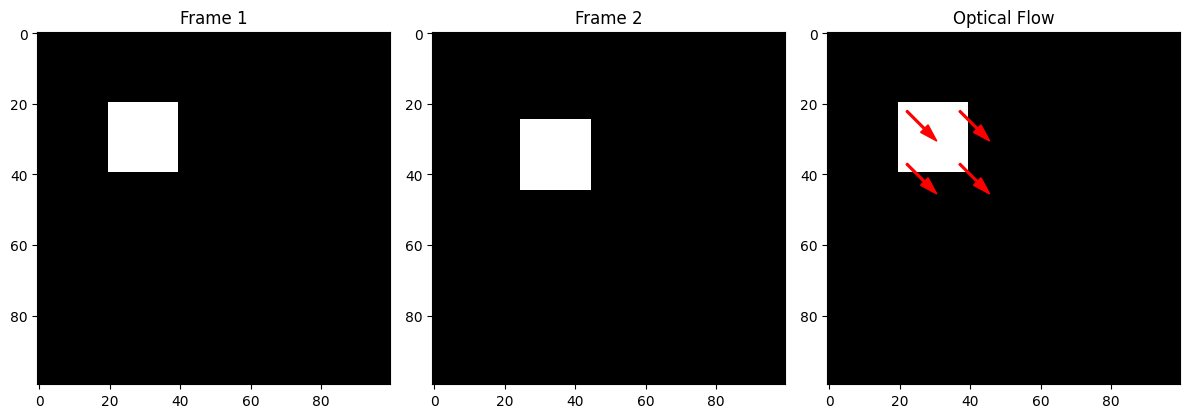

Point 0: Movement from (37.00, 37.00) to (42.00, 42.00)
Point 1: Movement from (22.00, 37.00) to (27.00, 42.00)
Point 2: Movement from (37.00, 22.00) to (42.00, 27.00)
Point 3: Movement from (22.00, 22.00) to (27.00, 27.00)


In [3]:
# Calculate optical flow
prev_pts, curr_pts = calculate_optical_flow(frame1, frame2)

# Visualize the results
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
plt.title('Frame 1')

plt.subplot(132)
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title('Frame 2')

plt.subplot(133)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
for i, (prev, curr) in enumerate(zip(prev_pts, curr_pts)):
    x_prev, y_prev = prev.ravel()
    x_curr, y_curr = curr.ravel()
    plt.arrow(x_prev, y_prev, x_curr - x_prev, y_curr - y_prev,
              color='r', width=0.5, head_width=3, head_length=5)
plt.title('Optical Flow')

plt.tight_layout()
plt.show()

# Print the flow vectors
for i, (prev, curr) in enumerate(zip(prev_pts, curr_pts)):
    x_prev, y_prev = prev.ravel()
    x_curr, y_curr = curr.ravel()
    print(f"Point {i}: Movement from ({x_prev:.2f}, {y_prev:.2f}) to ({x_curr:.2f}, {y_curr:.2f})")

In [4]:
# video
!gdown 1RfNxo4AFAdTuzkIRc5jtYzC_-HrugKFu

Downloading...
From (original): https://drive.google.com/uc?id=1RfNxo4AFAdTuzkIRc5jtYzC_-HrugKFu
From (redirected): https://drive.google.com/uc?id=1RfNxo4AFAdTuzkIRc5jtYzC_-HrugKFu&confirm=t&uuid=bbc007c2-0aa0-46d7-89c6-c9aca454400b
To: /content/empty4.mp4
100% 395M/395M [00:07<00:00, 56.4MB/s]


In [5]:
cap = cv2.VideoCapture('/content/empty4.mp4')
ret, frame1 = cap.read()
ret = cap.grab()
ret = cap.grab()
ret, frame2 = cap.read()
cap.release()

In [6]:
# Calculate optical flow
prev_pts, curr_pts = calculate_optical_flow(frame1, frame2)

In [7]:
# Print the flow vectors
for i, (prev, curr) in enumerate(zip(prev_pts, curr_pts)):
    x_prev, y_prev = prev.ravel()
    x_curr, y_curr = curr.ravel()
    print(f"Point {i}: Movement from ({x_prev:.2f}, {y_prev:.2f}) to ({x_curr:.2f}, {y_curr:.2f})")

Point 0: Movement from (1745.00, 77.00) to (1745.05, 77.01)
Point 1: Movement from (1600.00, 63.00) to (1599.99, 63.01)
Point 2: Movement from (1724.00, 51.00) to (1724.03, 50.99)
Point 3: Movement from (1501.00, 77.00) to (1501.00, 77.00)
Point 4: Movement from (1558.00, 68.00) to (1558.00, 68.00)
Point 5: Movement from (66.00, 1005.00) to (65.99, 1005.00)
Point 6: Movement from (1501.00, 55.00) to (1501.00, 55.00)
Point 7: Movement from (1453.00, 76.00) to (1453.00, 76.00)
Point 8: Movement from (1537.00, 63.00) to (1537.00, 62.99)
Point 9: Movement from (1608.00, 68.00) to (1608.00, 68.00)
Point 10: Movement from (1587.00, 72.00) to (1586.99, 72.00)
Point 11: Movement from (1647.00, 78.00) to (1647.02, 78.01)
Point 12: Movement from (1545.00, 68.00) to (1545.00, 68.00)
Point 13: Movement from (69.00, 1023.00) to (69.00, 1023.00)
Point 14: Movement from (1563.00, 570.00) to (1557.43, 588.78)
Point 15: Movement from (1706.00, 50.00) to (1706.00, 50.01)
Point 16: Movement from (1809.00

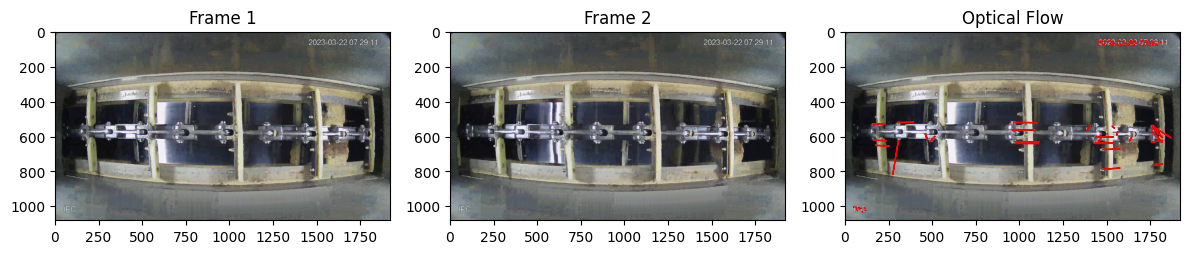

In [8]:
# Visualize the results
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
plt.title('Frame 1')

plt.subplot(132)
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title('Frame 2')

plt.subplot(133)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
for i, (prev, curr) in enumerate(zip(prev_pts, curr_pts)):
    x_prev, y_prev = prev.ravel()
    x_curr, y_curr = curr.ravel()
    plt.arrow(x_prev, y_prev, x_curr - x_prev, y_curr - y_prev,
              color='r', width=0.5, head_width=3, head_length=5)
plt.title('Optical Flow')


plt.tight_layout()
plt.show()

## โจทย์แล็ปปฏิบัติการ Optical Flow
1. ปรับเปลี่ยนพารามิเตอร์ต่อไปนี้ในฟังก์ชัน `calculate_optical_flow` และสังเกตผลกระทบ:
   - `maxCorners`: ลองใช้ค่า 50, 100 และ 200
   - `qualityLevel`: ลองใช้ค่า 0.005, 0.01 และ 0.05
   - `minDistance`: ลองใช้ค่า 5, 10 และ 15

2. สำหรับการเปลี่ยนแปลงพารามิเตอร์แต่ละครั้ง:
   - บันทึกภาพหน้าจอของการแสดงผล optical flow
   - อธิบายว่าพารามิเตอร์แต่ละตัวส่งผลต่อสิ่งต่อไปนี้อย่างไร:
     - จำนวนจุดที่ติดตาม
     - ความแม่นยำของการประมาณ optical flow
     - การกระจายตัวของจุดคุณลักษณะ (feature points)

## การประยุกต์ใช้จริง
3. บันทึกหรือดาวน์โหลดวิดีโอสองประเภทที่แตกต่างกัน (ความยาว 10-15 วินาทีต่อวิดีโอ):
   - วิดีโอที่มีวัตถุเคลื่อนที่วัตถุเดียวบนพื้นหลังที่อยู่นิ่ง
   - วิดีโอที่มีกล้องเคลื่อนที่ (เช่น การแพนกล้องไปทั่วฉาก)

4. สำหรับวิดีโอแต่ละรายการ:
   - แยกสองเฟรมที่ต่อเนื่องกัน หรืออาจห่างกัน3-4 เฟรมหากต้องการ flow vector ที่ยาวขึ้น
   - ใช้อัลกอริทึม optical flow
   - แสดงภาพของเวกเตอร์การไหล
   - วิเคราะห์ความแตกต่างของรูปแบบการไหลระหว่างสองสถานการณ์

5. เปลี่ยนไปใช้ dense optical flow โดยใช้วิธี Farneback  [(`cv2.calcOpticalFlowFarneback()`)](https://docs.opencv.org/4.x/d4/dee/tutorial_optical_flow.html)
   - เปรียบเทียบผลลัพธ์กับวิธี sparse Lucas-Kanade
   - อภิปรายข้อดีและข้อเสียของแต่ละวิธี

#1. ปรับเปลี่ยนพารามิเตอร์ต่อไปนี้ในฟังก์ชัน `calculate_optical_flow` และสังเกตผลกระทบ:
   - `maxCorners`: ลองใช้ค่า 50, 100 และ 200
   - `qualityLevel`: ลองใช้ค่า 0.005, 0.01 และ 0.05
   - `minDistance`: ลองใช้ค่า 5, 10 และ 15


In [18]:
def calculate_optical_flow(frame1, frame2, maxcorners, qualitylevel, mindist):
    # Convert frames to grayscale
    prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # Find good features to track
    prev_pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=maxcorners, qualityLevel=qualitylevel, minDistance=mindist, blockSize=7)

    # Calculate optical flow
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)

    # Select good points
    good_prev = prev_pts[status == 1]
    good_curr = curr_pts[status == 1]

    return good_prev, good_curr

maxcorner
Environment: {'maxcorner': 50, 'qualitylevel': 0.01, 'mindist': 7}


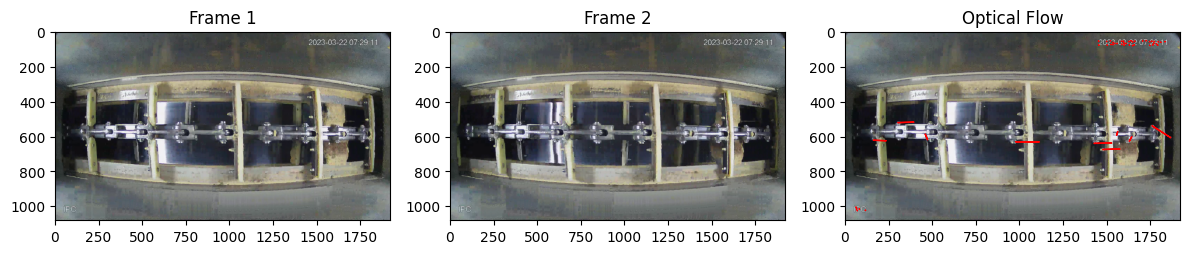

Environment: {'maxcorner': 100, 'qualitylevel': 0.01, 'mindist': 7}


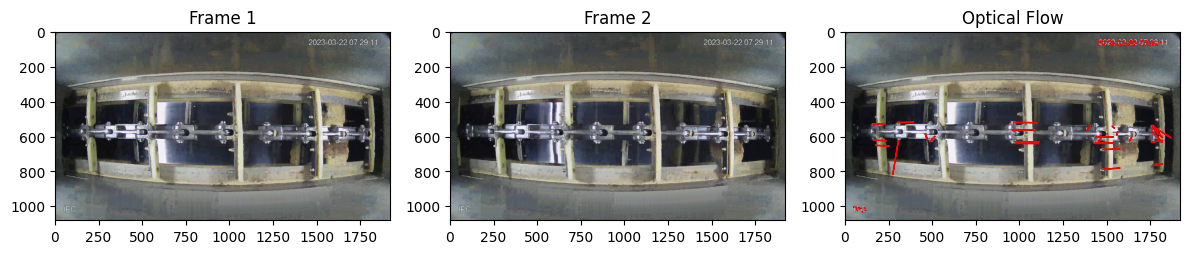

Environment: {'maxcorner': 200, 'qualitylevel': 0.01, 'mindist': 7}


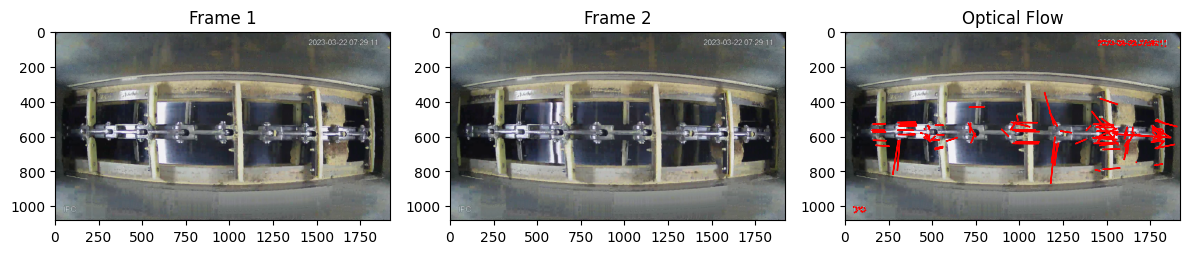




qualitylevel
Environment: {'maxcorner': 100, 'qualitylevel': 0.005, 'mindist': 7}


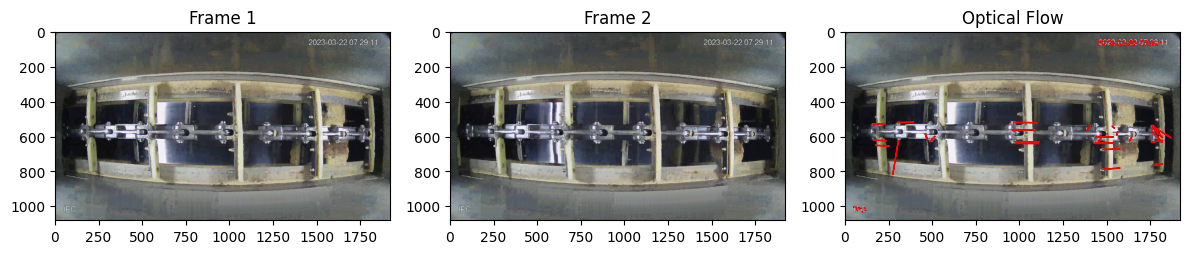

Environment: {'maxcorner': 100, 'qualitylevel': 0.01, 'mindist': 7}


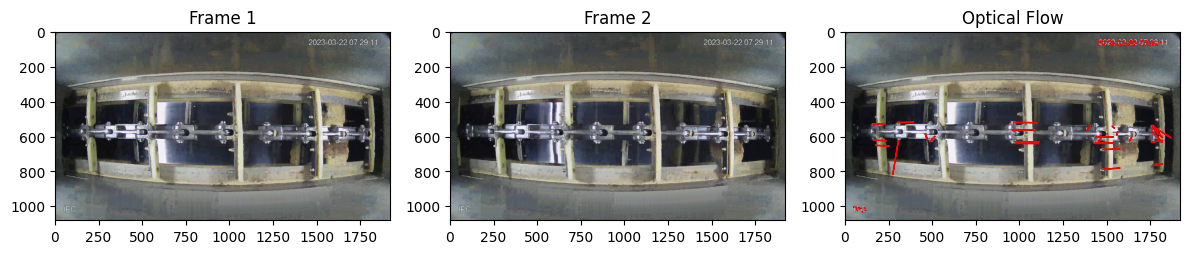

Environment: {'maxcorner': 100, 'qualitylevel': 0.05, 'mindist': 7}


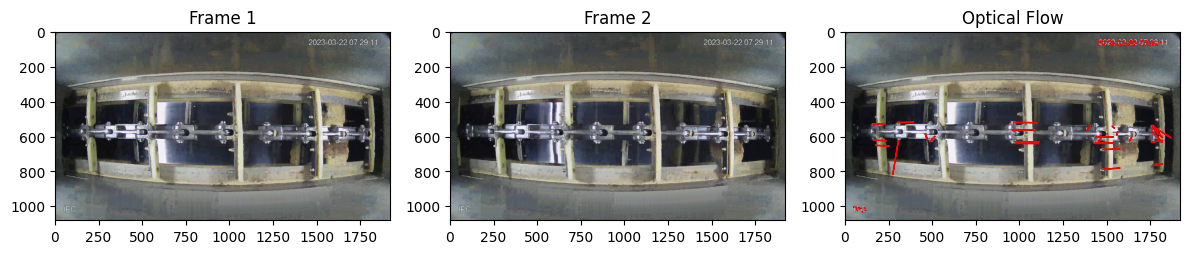




mindist
Environment: {'maxcorner': 100, 'qualitylevel': 0.01, 'mindist': 5}


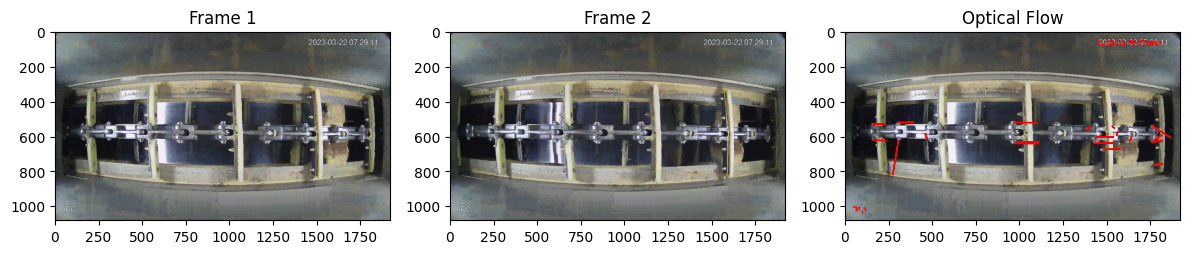

Environment: {'maxcorner': 100, 'qualitylevel': 0.01, 'mindist': 10}


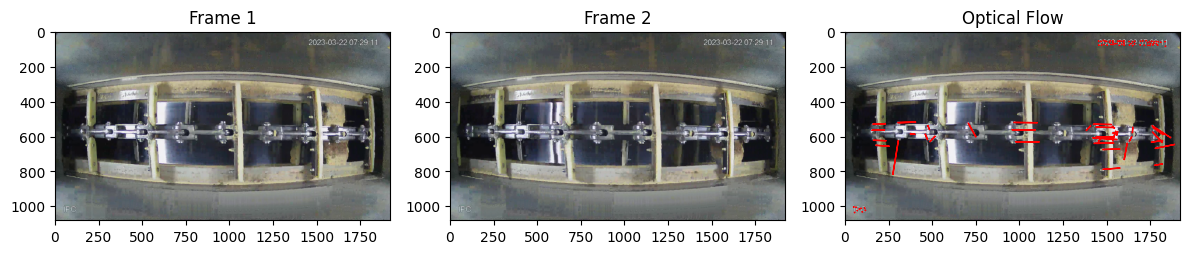

Environment: {'maxcorner': 100, 'qualitylevel': 0.01, 'mindist': 15}


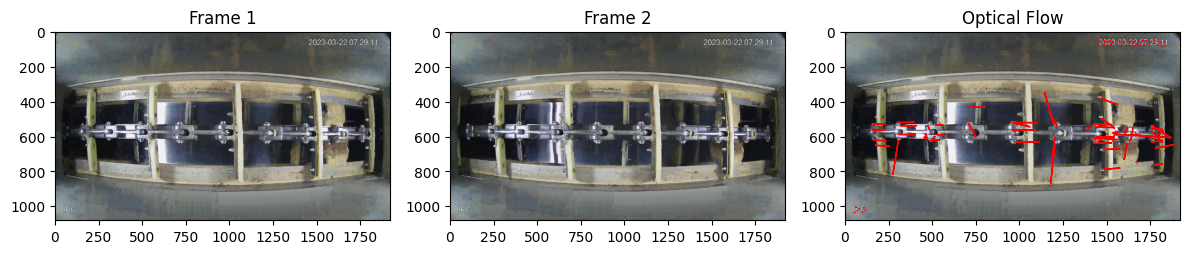

In [19]:
import cv2
import matplotlib.pyplot as plt

def load_video_frames(video_path, skip_frame=2):
    cap = cv2.VideoCapture(video_path)
    _, frame1 = cap.read()
    for _ in range(skip_frame):
      cap.grab()
    _, frame2 = cap.read()
    cap.release()
    return frame1, frame2

def plot_optical_flow(frame1, frame2, params):
    prev_pts, curr_pts = calculate_optical_flow(
        frame1, frame2,
        maxcorners=params['maxcorner'],
        qualitylevel=params['qualitylevel'],
        mindist=params['mindist']
    )

    print(f"Environment: {params}")

    plt.figure(figsize=(12, 4))
    for i, (title, frame) in enumerate(zip([
        'Frame 1', 'Frame 2', 'Optical Flow'], [frame1, frame2, frame1])):
        plt.subplot(1, 3, i + 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(title)
        if title == 'Optical Flow':
            for prev, curr in zip(prev_pts, curr_pts):
                plt.arrow(*prev.ravel(), *(curr - prev).ravel(),
                          color='r', width=0.5, head_width=3, head_length=5)
    plt.tight_layout()
    plt.show()


frame1, frame2 = load_video_frames('/content/empty4.mp4')
param_variations = {
    'maxcorner': [50, 100, 200],
    'qualitylevel': [0.005, 0.01, 0.05],
    'mindist': [5, 10, 15]
}

for key, values in param_variations.items():
    print(key)
    for value in values:
        params = {'maxcorner': 100, 'qualitylevel': 0.01, 'mindist': 7}
        params[key] = value
        plot_optical_flow(frame1, frame2, params)
    print('\n\n')


# 2. สำหรับการเปลี่ยนแปลงพารามิเตอร์แต่ละครั้ง:
   - บันทึกภาพหน้าจอของการแสดงผล optical flow
   - อธิบายว่าพารามิเตอร์แต่ละตัวส่งผลต่อสิ่งต่อไปนี้อย่างไร:
     - จำนวนจุดที่ติดตาม
     - ความแม่นยำของการประมาณ optical flow
     - การกระจายตัวของจุดคุณลักษณะ (feature points)

Ans: เมื่อ maxcorner สูงขึ้นจะทำให้ feature point มากขึ้นไปด้วย ในส่วนของ qualitylevel หากเพิ่มมากขึ้นก็จะบ่งบอกถึงความแม่นยำของ optical flow ที่สูงขึ้นด้วย และ mindist หากมีค่ามากขึ้นจะมีการกระจายตัวของ feature point ที่มากขึ้น

# 4. สำหรับวิดีโอแต่ละรายการ:
   - แยกสองเฟรมที่ต่อเนื่องกัน หรืออาจห่างกัน3-4 เฟรมหากต้องการ flow vector ที่ยาวขึ้น
   - ใช้อัลกอริทึม optical flow
   - แสดงภาพของเวกเตอร์การไหล
   - วิเคราะห์ความแตกต่างของรูปแบบการไหลระหว่างสองสถานการณ์

## วิดีโอที่มีวัตถุเคลื่อนที่วัตถุเดียวบนพื้นหลังที่อยู่นิ่ง

In [20]:
def calculate_optical_flow(frame1, frame2):
    # Convert frames to grayscale
    prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # Find good features to track
    prev_pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=100, qualityLevel=0.01, minDistance=7, blockSize=7)

    # Calculate optical flow
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)

    # Select good points
    good_prev = prev_pts[status == 1]
    good_curr = curr_pts[status == 1]

    return good_prev, good_curr

Point 0: Movement from (342.00, 228.00) to (355.34, 323.62)
Point 1: Movement from (329.00, 319.00) to (329.75, 320.97)
Point 2: Movement from (37.00, 317.00) to (38.49, 319.92)
Point 3: Movement from (4.00, 635.00) to (5.79, 637.77)
Point 4: Movement from (5.00, 626.00) to (6.82, 628.69)
Point 5: Movement from (350.00, 586.00) to (315.76, 583.55)
Point 6: Movement from (220.00, 321.00) to (192.10, 316.39)
Point 7: Movement from (27.00, 665.00) to (-0.59, 662.48)
Point 8: Movement from (335.00, 380.00) to (335.28, 394.41)
Point 9: Movement from (353.00, 387.00) to (353.38, 399.62)
Point 10: Movement from (254.00, 844.00) to (223.68, 848.71)
Point 11: Movement from (117.00, 953.00) to (119.10, 956.39)
Point 12: Movement from (149.00, 625.00) to (118.00, 638.05)
Point 13: Movement from (305.00, 332.00) to (271.83, 335.64)
Point 14: Movement from (382.00, 606.00) to (352.33, 627.69)
Point 15: Movement from (364.00, 624.00) to (335.36, 625.58)
Point 16: Movement from (38.00, 185.00) to (39

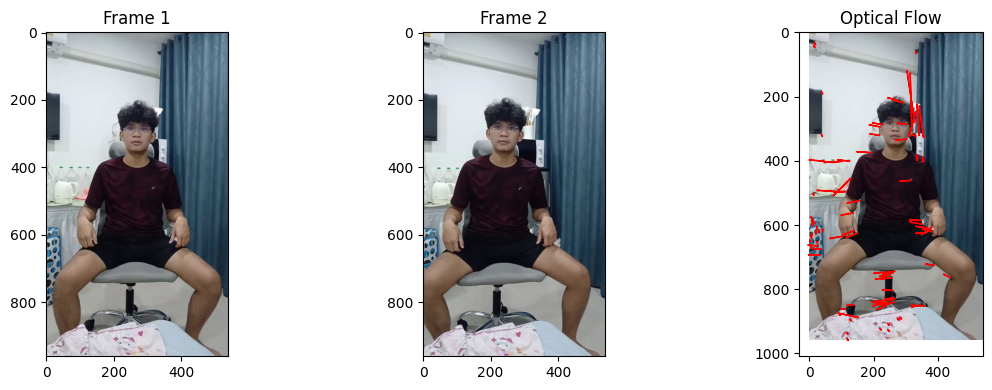

In [24]:
import numpy as np
import cv2 as cv

frame1, frame2 = load_video_frames('/content/oil_move.mp4', skip_frame=25)

prev_pts, curr_pts = calculate_optical_flow(frame1, frame2)

# Print the flow vectors
for i, (prev, curr) in enumerate(zip(prev_pts, curr_pts)):
    x_prev, y_prev = prev.ravel()
    x_curr, y_curr = curr.ravel()
    print(f"Point {i}: Movement from ({x_prev:.2f}, {y_prev:.2f}) to ({x_curr:.2f}, {y_curr:.2f})")

# Visualize the results
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
plt.title('Frame 1')

plt.subplot(132)
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title('Frame 2')

plt.subplot(133)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
for i, (prev, curr) in enumerate(zip(prev_pts, curr_pts)):
    x_prev, y_prev = prev.ravel()
    x_curr, y_curr = curr.ravel()
    plt.arrow(x_prev, y_prev, x_curr - x_prev, y_curr - y_prev,
              color='r', width=0.5, head_width=3, head_length=5)
plt.title('Optical Flow')


plt.tight_layout()
plt.show()

## วิดีโอที่มีกล้องเคลื่อนที่

Point 0: Movement from (230.00, 407.00) to (176.38, 409.99)
Point 1: Movement from (275.00, 91.00) to (225.21, 95.97)
Point 2: Movement from (245.00, 450.00) to (191.03, 453.42)
Point 3: Movement from (267.00, 430.00) to (213.48, 433.70)
Point 4: Movement from (284.00, 91.00) to (234.25, 96.32)
Point 5: Movement from (211.00, 442.00) to (156.36, 444.95)
Point 6: Movement from (272.00, 406.00) to (218.76, 409.71)
Point 7: Movement from (422.00, 102.00) to (370.31, 112.49)
Point 8: Movement from (263.00, 752.00) to (204.00, 756.09)
Point 9: Movement from (244.00, 443.00) to (190.03, 446.36)
Point 10: Movement from (211.00, 450.00) to (156.36, 452.98)
Point 11: Movement from (257.00, 555.00) to (201.51, 558.66)
Point 12: Movement from (138.00, 294.00) to (84.12, 294.20)
Point 13: Movement from (518.00, 809.00) to (453.15, 809.51)
Point 14: Movement from (280.00, 705.00) to (222.18, 708.64)
Point 15: Movement from (228.00, 793.00) to (168.43, 797.58)
Point 16: Movement from (344.00, 353.00

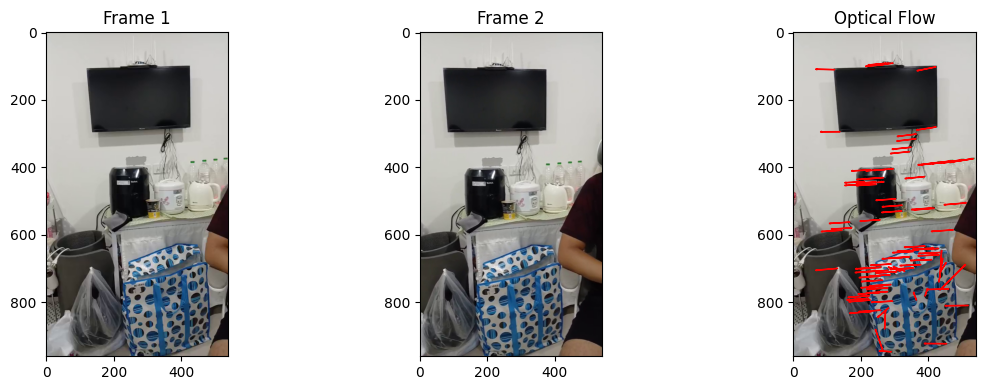

In [25]:
import numpy as np
import cv2 as cv

frame1, frame2 = load_video_frames('/content/cam_move.mp4', skip_frame=25)

prev_pts, curr_pts = calculate_optical_flow(frame1, frame2)

# Print the flow vectors
for i, (prev, curr) in enumerate(zip(prev_pts, curr_pts)):
    x_prev, y_prev = prev.ravel()
    x_curr, y_curr = curr.ravel()
    print(f"Point {i}: Movement from ({x_prev:.2f}, {y_prev:.2f}) to ({x_curr:.2f}, {y_curr:.2f})")

# Visualize the results
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
plt.title('Frame 1')

plt.subplot(132)
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title('Frame 2')

plt.subplot(133)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
for i, (prev, curr) in enumerate(zip(prev_pts, curr_pts)):
    x_prev, y_prev = prev.ravel()
    x_curr, y_curr = curr.ravel()
    plt.arrow(x_prev, y_prev, x_curr - x_prev, y_curr - y_prev,
              color='r', width=0.5, head_width=3, head_length=5)
plt.title('Optical Flow')


plt.tight_layout()
plt.show()

# 5. เปลี่ยนไปใช้ dense optical flow โดยใช้วิธี Farneback  [(`cv2.calcOpticalFlowFarneback()`)](https://docs.opencv.org/4.x/d4/dee/tutorial_optical_flow.html)
   - เปรียบเทียบผลลัพธ์กับวิธี sparse Lucas-Kanade
   - อภิปรายข้อดีและข้อเสียของแต่ละวิธี

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_video_frames(video_path, skip_frame=2):
    cap = cv2.VideoCapture(video_path)
    _, frame1 = cap.read()
    for _ in range(skip_frame):
        cap.grab()
    _, frame2 = cap.read()
    cap.release()
    return frame1, frame2

def plot_optical_flow_farneback(frame1, frame2):
    prvs = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    next = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(prvs, next, None, 0.5, 3, 15, 3, 5, 1.2, 0)

    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv = np.zeros_like(frame1)
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 1] = 255
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    plt.figure(figsize=(12, 4))

    plt.subplot(131)
    plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
    plt.title('Frame 1')

    plt.subplot(132)
    plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
    plt.title('Frame 2')

    plt.subplot(133)
    plt.imshow(bgr)
    plt.title('Optical Flow')

    plt.tight_layout()
    plt.show()


## วิดีโอที่มีวัตถุเคลื่อนที่วัตถุเดียวบนพื้นหลังที่อยู่นิ่ง

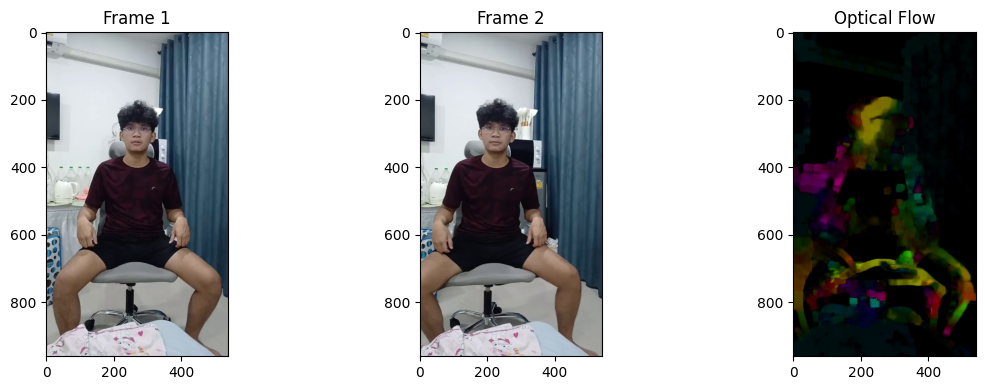

In [28]:
frame1, frame2 = load_video_frames('/content/oil_move.mp4', skip_frame=30)
plot_optical_flow_farneback(frame1, frame2)

## วิดีโอที่มีกล้องเคลื่อนที่

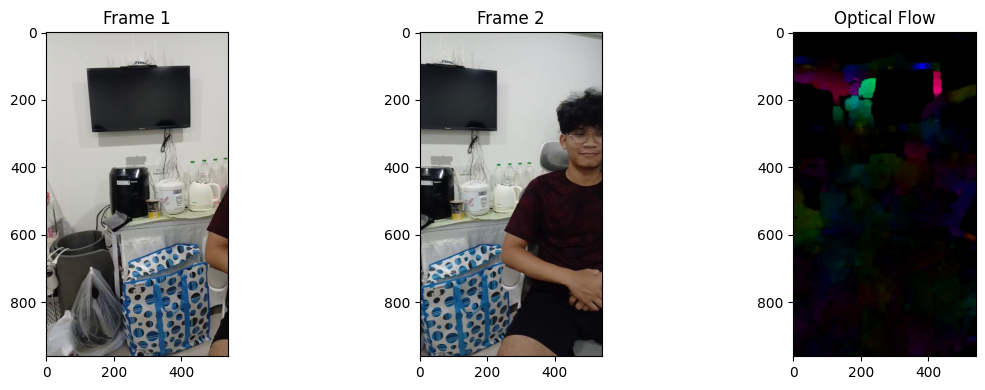

In [34]:
frame1, frame2 = load_video_frames('/content/cam_move.mp4', skip_frame=55)
plot_optical_flow_farneback(frame1, frame2)